In [3]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
import pandas as pd
import numpy as np
import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # if using multi-GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained("vinai/bertweet-base", use_fast=False)

# Custom Dataset
class OpinionDataset(Dataset):
    def __init__(self, texts, level1, level2, level3, tokenizer, max_len=128):
        self.texts = texts
        self.level1 = level1
        self.level2 = level2
        self.level3 = level3
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(self.texts[idx], truncation=True, padding='max_length',
                                  max_length=self.max_len, return_tensors='pt')
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label1': torch.tensor(self.level1[idx], dtype=torch.long),
            'label2': torch.tensor(-1 if pd.isna(self.level2[idx]) else self.level2[idx], dtype=torch.long),
            'label3': torch.tensor(-1 if pd.isna(self.level3[idx]) else self.level3[idx], dtype=torch.long),
            'text': self.texts[idx]
        }

# Hierarchical Model
class HierarchicalBertweet(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = AutoModel.from_pretrained("vinai/bertweet-base")
        self.dropout = nn.Dropout(0.3)
        self.classifier1 = nn.Linear(768, 3)
        self.classifier2 = nn.Linear(768, 3)
        self.classifier3 = nn.Linear(768, 4)

    def forward(self, input_ids, attention_mask):
        output = self.bert(input_ids=input_ids, attention_mask=attention_mask)[0][:, 0]  # CLS token
        x = self.dropout(output)
        out1 = self.classifier1(x)
        out2 = self.classifier2(x)
        out3 = self.classifier3(x)
        return out1, out2, out3

config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [11]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm
import torch
import torch.nn as nn
import pandas as pd
from torch.utils.data import DataLoader

def train_and_evaluate(df, tokenizer, epochs=3, batch_size=16, folds=10):
    skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)

    all_preds1, all_labels1 = [], []
    all_preds2, all_labels2 = [], []
    all_preds3, all_labels3 = [], []

    misclassified_data = []
    for fold, (train_idx, val_idx) in enumerate(skf.split(df['text'], df['level1'])):
        print(f"\n====== Fold {fold+1} ======")
        train_df = df.iloc[train_idx]
        val_df = df.iloc[val_idx]

        train_dataset = OpinionDataset(train_df['text'].tolist(), train_df['level1'].tolist(),
                                       train_df['level2'].tolist(), train_df['level3'].tolist(), tokenizer)
        val_dataset = OpinionDataset(val_df['text'].tolist(), val_df['level1'].tolist(),
                                     val_df['level2'].tolist(), val_df['level3'].tolist(), tokenizer)

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size)

        model = HierarchicalBertweet().cuda()
        optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
        loss_fn = nn.CrossEntropyLoss(ignore_index=-1)
        best_score = 0.0
        best_model_path = f"best_model_fold{fold+1}.pt"
        for epoch in range(epochs):
            model.train()
            for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
                input_ids = batch['input_ids'].cuda()
                attention_mask = batch['attention_mask'].cuda()
                label1 = batch['label1'].cuda()
                label2 = batch['label2'].cuda()
                label3 = batch['label3'].cuda()

                out1, out2, out3 = model(input_ids, attention_mask)
                loss1 = loss_fn(out1, label1)
                loss2 = loss_fn(out2, label2)
                loss3 = loss_fn(out3, label3)
                loss = loss1 + loss2 + loss3

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            # Evaluation after each epoch
            model.eval()
            val_true1, val_pred1 = [], []
            val_true2, val_pred2 = [], []
            val_true3, val_pred3 = [], []

            with torch.no_grad():
                for batch in val_loader:
                    input_ids = batch['input_ids'].cuda()
                    attention_mask = batch['attention_mask'].cuda()
                    label1 = batch['label1']
                    label2 = batch['label2']
                    label3 = batch['label3']

                    out1, out2, out3 = model(input_ids, attention_mask)
                    pred1 = torch.argmax(out1, dim=1).cpu()
                    pred2 = torch.argmax(out2, dim=1).cpu()
                    pred3 = torch.argmax(out3, dim=1).cpu()

                    val_true1.extend(label1.tolist())
                    val_pred1.extend(pred1.tolist())

                    for i in range(len(label1)):
                        if label1[i] == 2:
                            val_true2.append(label2[i].item())
                            val_pred2.append(pred2[i].item())
                            if label2[i] == 0:
                                val_true3.append(label3[i].item())
                                val_pred3.append(pred3[i].item())

            lev1_acc = accuracy_score(val_true1, val_pred1)
            lev1_f1 = f1_score(val_true1, val_pred1, average='weighted')
            combined_score = lev1_acc + lev1_f1

            print(f"\n📊 Epoch {epoch+1} Evaluation:")
            print(f"  Level 1 Accuracy: {lev1_acc:.4f}, F1: {lev1_f1:.4f}, Score: {combined_score:.4f}")
            if val_true2:
                print(f"  Level 2 Accuracy: {accuracy_score(val_true2, val_pred2):.4f}, F1: {f1_score(val_true2, val_pred2, average='weighted'):.4f}")
            if val_true3:
                print(f"  Level 3 Accuracy: {accuracy_score(val_true3, val_pred3):.4f}, F1: {f1_score(val_true3, val_pred3, average='weighted'):.4f}")

            if combined_score > best_score:
                best_score = combined_score
                torch.save(model.state_dict(), best_model_path)
                print(f"💾 Best model saved at Epoch {epoch+1} with score = {combined_score:.4f}")

        # Load best model and evaluate
        model.load_state_dict(torch.load(best_model_path))
        model.eval()
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].cuda()
                attention_mask = batch['attention_mask'].cuda()
                label1 = batch['label1']
                label2 = batch['label2']
                label3 = batch['label3']
                texts = batch['text']

                out1, out2, out3 = model(input_ids, attention_mask)
                pred1 = torch.argmax(out1, dim=1).cpu()
                pred2 = torch.argmax(out2, dim=1).cpu()
                pred3 = torch.argmax(out3, dim=1).cpu()

                for i in range(len(texts)):
                    all_preds1.append(pred1[i].item())
                    all_labels1.append(label1[i].item())

                    if label1[i] == 2:
                        all_preds2.append(pred2[i].item())
                        all_labels2.append(label2[i].item())

                        if label2[i] == 0:
                            all_preds3.append(pred3[i].item())
                            all_labels3.append(label3[i].item())

                            if label3[i].item() != pred3[i].item():
                                misclassified_data.append({
                                    "text": texts[i],
                                    "true_level1": label1[i].item(), "pred_level1": pred1[i].item(),
                                    "true_level2": label2[i].item(), "pred_level2": pred2[i].item(),
                                    "true_level3": label3[i].item(), "pred_level3": pred3[i].item()
                                })
                    elif label1[i].item() != pred1[i].item():
                        misclassified_data.append({
                            "text": texts[i],
                            "true_level1": label1[i].item(), "pred_level1": pred1[i].item()
                        })

    return (all_labels1, all_preds1,
            all_labels2, all_preds2,
            all_labels3, all_preds3,
            pd.DataFrame(misclassified_data),
            model)


In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def print_results(y_true1, y_pred1, y_true2, y_pred2, y_true3, y_pred3, misclassified_df):
    print("\n===== Level 1 Results =====")
    print(classification_report(y_true1, y_pred1, target_names=["NOISE", "OBJECTIVE", "SUBJECTIVE"]))
    print(confusion_matrix(y_true1, y_pred1))

    print("\n===== Level 2 Results (SUBJECTIVE only) =====")
    print(classification_report(y_true2, y_pred2, target_names=["NEUTRAL", "NEGATIVE", "POSITIVE"]))
    print(confusion_matrix(y_true2, y_pred2))

    print("\n===== Level 3 Results (NEUTRAL only) =====")
    print(classification_report(y_true3, y_pred3, target_names=["NEUTRAL", "QUESTIONS", "ADS", "MISC"]))
    print(confusion_matrix(y_true3, y_pred3))

    print(f"\nTotal misclassified examples: {len(misclassified_df)}")
    print(misclassified_df.head())

    # Optional: Heatmaps
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, cm, title in zip(axes, 
                             [confusion_matrix(y_true1, y_pred1),
                              confusion_matrix(y_true2, y_pred2),
                              confusion_matrix(y_true3, y_pred3)],
                             ["Level 1", "Level 2", "Level 3"]):
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
        ax.set_title(f"{title} Confusion Matrix")
    plt.tight_layout()
    plt.show()


====== Fold 1 ======


Epoch 1: 100%|██████████| 254/254 [00:51<00:00,  4.94it/s]



📊 Epoch 1 Evaluation:
  Level 1 Accuracy: 0.9133, F1: 0.9095, Score: 1.8228
  Level 2 Accuracy: 0.8242, F1: 0.7644
  Level 3 Accuracy: 0.8078, F1: 0.7795
💾 Best model saved at Epoch 1 with score = 1.8228


Epoch 2: 100%|██████████| 254/254 [00:51<00:00,  4.94it/s]



📊 Epoch 2 Evaluation:
  Level 1 Accuracy: 0.9222, F1: 0.9217, Score: 1.8439
  Level 2 Accuracy: 0.8703, F1: 0.8591
  Level 3 Accuracy: 0.8434, F1: 0.8456
💾 Best model saved at Epoch 2 with score = 1.8439


...


📊 Epoch 1 Evaluation:
  Level 1 Accuracy: 0.8822, F1: 0.8813, Score: 1.7635
  Level 2 Accuracy: 0.8150, F1: 0.7728
  Level 3 Accuracy: 0.8824, F1: 0.8685
💾 Best model saved at Epoch 1 with score = 1.7635


Epoch 2: 100%|██████████| 254/254 [00:51<00:00,  4.93it/s]



📊 Epoch 2 Evaluation:
  Level 1 Accuracy: 0.8911, F1: 0.8883, Score: 1.7794
  Level 2 Accuracy: 0.8699, F1: 0.8483
  Level 3 Accuracy: 0.9081, F1: 0.9031
💾 Best model saved at Epoch 2 with score = 1.7794


Epoch 3: 100%|██████████| 254/254 [00:51<00:00,  4.93it/s]



📊 Epoch 3 Evaluation:
  Level 1 Accuracy: 0.9000, F1: 0.8977, Score: 1.7977
  Level 2 Accuracy: 0.8699, F1: 0.8386
  Level 3 Accuracy: 0.9118, F1: 0.9058
💾 Best model saved at Epoch 3 with score = 1.7977

===== Level 1 Results =====
              precision    recall  f1-score   support

       NOISE       0.85      0.69      0.76       580
   OBJECTIVE       0.81      0.85      0.83       453
  SUBJECTIVE       0.94      0.96      0.95      3467

    accuracy                           0.92      4500
   macro avg       0.87      0.83      0.85      4500
weighted avg       0.92      0.92      0.91      4500

[[ 400   23  157]
 [  11  384   58]
 [  58   67 3342]]

===== Level 2 Results (SUBJECTIVE only) =====
              precision    recall  f1-score   support

     NEUTRAL       0.91      0.96      0.93      2865
    NEGATIVE       0.63      0.54      0.58       369
    POSITIVE       0.52      0.23      0.32       233

    accuracy                           0.87      3467
   macro av

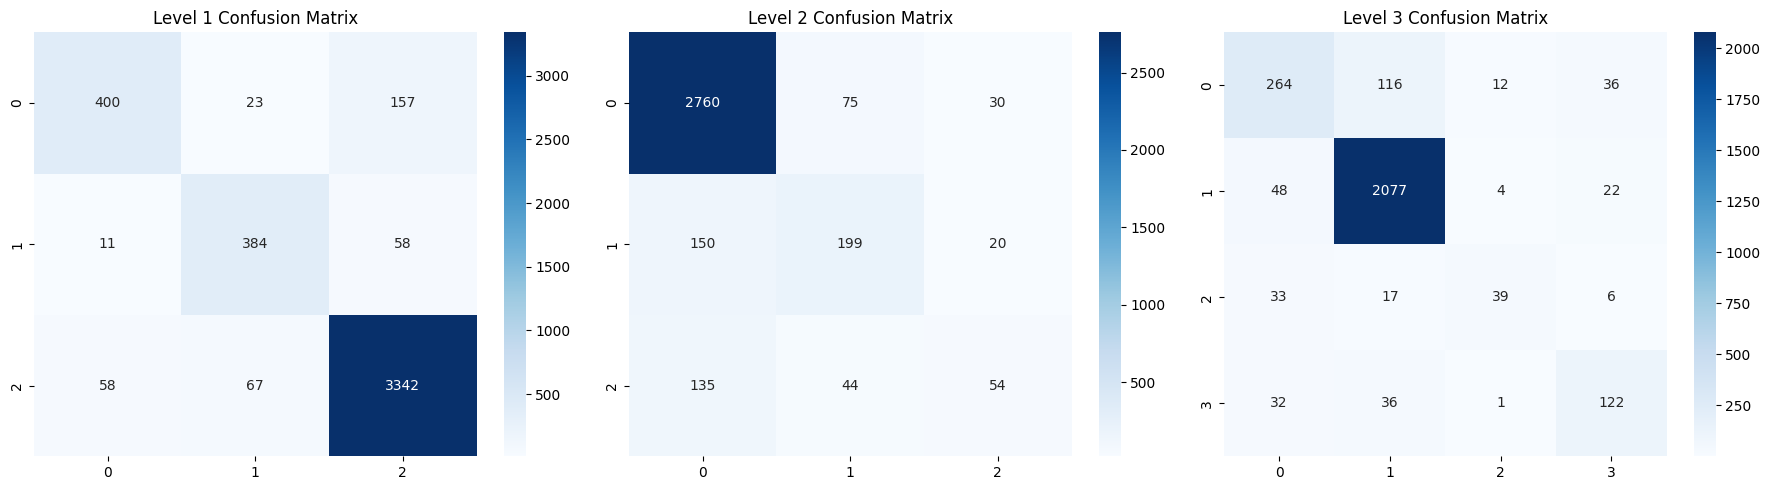

In [13]:
df = pd.read_csv("/kaggle/input/train-task1/reddit_train.csv")
df.rename(columns={
    "MAIN": "text",
    "Level 1": "level1",
    "Level 2": "level2",
    "Level 3": "level3"
}, inplace=True)
(y1, p1, y2, p2, y3, p3, misclassified_df,model) = train_and_evaluate(df, tokenizer)
print_results(y1, p1, y2, p2, y3, p3, misclassified_df)

In [21]:
model = HierarchicalBertweet()
model.load_state_dict(torch.load("/kaggle/working/best_model_fold9.pt"))  # or your specific path
model.cuda()
test_df = pd.read_csv("/kaggle/input/train-task1/reddit_test.csv")
test_df.rename(columns={
    "MAIN": "text",
    "Level 1": "level1",
    "Level 2": "level2",
    "Level 3": "level3"
}, inplace=True)

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from collections import Counter

def print_classwise_accuracy(y_true, y_pred, label_names, level_name):
    cm = confusion_matrix(y_true, y_pred)
    correct_per_class = cm.diagonal()
    total_per_class = cm.sum(axis=1)
    print(f"\nClass-wise Accuracy for {level_name}:")
    for i, label in enumerate(label_names):
        acc = 100.0 * correct_per_class[i] / total_per_class[i] if total_per_class[i] > 0 else 0.0
        print(f"  {label:<20} : {acc:.2f}% ({correct_per_class[i]}/{total_per_class[i]})")
        
def evaluate_on_test(model, test_df, tokenizer, batch_size=16):
    test_dataset = OpinionDataset(test_df['text'].tolist(),
                                   test_df['level1'].tolist(),
                                   test_df['level2'].tolist(),
                                   test_df['level3'].tolist(), tokenizer)
    
    test_loader = DataLoader(test_dataset, batch_size=batch_size)
    
    model.eval()
    model.cuda()
    
    y_true1, y_pred1 = [], []
    y_true2, y_pred2 = [], []
    y_true3, y_pred3 = [], []

    label1_names = ["NOISE", "OBJECTIVE", "SUBJECTIVE"]
    label2_names = ["NEUTRAL", "NEGATIVE", "POSITIVE"]
    label3_names = ["NEUTRAL SENTIMENT", "QUESTIONS", "ADVERTISEMENTS", "MISCELLANEOUS"]
    
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].cuda()
            attention_mask = batch['attention_mask'].cuda()
            label1 = batch['label1']
            label2 = batch['label2']
            label3 = batch['label3']
            
            out1, out2, out3 = model(input_ids, attention_mask)
            pred1 = torch.argmax(out1, dim=1).cpu()
            pred2 = torch.argmax(out2, dim=1).cpu()
            pred3 = torch.argmax(out3, dim=1).cpu()

            y_true1.extend(label1.tolist())
            y_pred1.extend(pred1.tolist())

            for i in range(len(label1)):
                if label1[i] == 2:
                    y_true2.append(label2[i].item())
                    y_pred2.append(pred2[i].item())
                    
                    if label2[i] == 0:
                        y_true3.append(label3[i].item())
                        y_pred3.append(pred3[i].item())
    
    print("\n===== Level 1 Test Results =====")
    print("Accuracy:", accuracy_score(y_true1, y_pred1))
    print("F1 Score:", f1_score(y_true1, y_pred1, average='weighted'))
    print("Confusion Matrix:\n", confusion_matrix(y_true1, y_pred1))
    print_classwise_accuracy(y_true1, y_pred1, label1_names, "Level 1")
    
    print("\nLevel 2 Accuracy (on Level 1=2):", accuracy_score(y_true2, y_pred2))
    print("Level 2 F1 Score:", f1_score(y_true2, y_pred2, average='weighted'))
    print("Confusion Matrix - Level 2:")
    print(confusion_matrix(y_true2, y_pred2))
    print_classwise_accuracy(y_true2, y_pred2, label2_names, "Level 2")

    print("\nLevel 3 Accuracy (on Level 2=0):", accuracy_score(y_true3, y_pred3))
    print("Level 3 F1 Score:", f1_score(y_true3, y_pred3, average='weighted'))
    print("Confusion Matrix - Level 3:")
    print(confusion_matrix(y_true3, y_pred3))
    print_classwise_accuracy(y_true3, y_pred3, label3_names, "Level 3")
evaluate_on_test(model, test_df, tokenizer)


===== Level 1 Test Results =====
Accuracy: 0.9
F1 Score: 0.901129731915378
Confusion Matrix:
 [[ 47   4  14]
 [  1  44   5]
 [ 10  16 359]]

Class-wise Accuracy for Level 1:
  NOISE                : 72.31% (47/65)
  OBJECTIVE            : 88.00% (44/50)
  SUBJECTIVE           : 93.25% (359/385)

Level 2 Accuracy (on Level 1=2): 0.8649350649350649
Level 2 F1 Score: 0.8637611140629251
Confusion Matrix - Level 2:
[[298  11   9]
 [ 13  22   6]
 [ 10   3  13]]

Class-wise Accuracy for Level 2:
  NEUTRAL              : 93.71% (298/318)
  NEGATIVE             : 53.66% (22/41)
  POSITIVE             : 50.00% (13/26)

Level 3 Accuracy (on Level 2=0): 0.8710691823899371
Level 3 F1 Score: 0.8591089898478884
Confusion Matrix - Level 3:
[[ 23  16   3   6]
 [  0 238   0   1]
 [  2   2   6   0]
 [  9   2   0  10]]

Class-wise Accuracy for Level 3:
  NEUTRAL SENTIMENT    : 47.92% (23/48)
  QUESTIONS            : 99.58% (238/239)
  ADVERTISEMENTS       : 60.00% (6/10)
  MISCELLANEOUS        : 47.62% (

In [17]:
test_df = pd.read_csv("/kaggle/input/train-task1/CRYPTO_REDDIT_TEST.csv")
texts = test_df['MAIN'].tolist()

class InferenceDataset(torch.utils.data.Dataset):
    def __init__(self, texts, tokenizer, max_len=128):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(self.texts[idx],
                                  padding='max_length',
                                  truncation=True,
                                  max_length=self.max_len,
                                  return_tensors='pt')
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0)
        }
        
test_dataset = InferenceDataset(texts, tokenizer)
test_loader = DataLoader(test_dataset, batch_size=16)

preds1, preds2, preds3 = [], [], []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Predicting"):
        input_ids = batch['input_ids'].cuda()
        attention_mask = batch['attention_mask'].cuda()

        out1, out2, out3 = model(input_ids, attention_mask)

        p1 = torch.argmax(out1, dim=1).cpu().tolist()
        p2 = torch.argmax(out2, dim=1).cpu().tolist()
        p3 = torch.argmax(out3, dim=1).cpu().tolist()

        preds1.extend(p1)
        preds2.extend(p2)
        preds3.extend(p3)
        
test_df["Level 1"] = preds1
test_df["Level 2"] = preds2
test_df["Level 3"] = preds3

test_df[["title", "selftext", "MAIN", "Level 1", "Level 2", "Level 3"]].to_csv("crypto_test_reddit.csv", index=False)

Predicting: 100%|██████████| 32/32 [00:02<00:00, 15.78it/s]
